# Lane Detection: Step-by-Step Visual Guide

This notebook shows **each stage** of the lane detection pipeline with images.
Run cells from top to bottom.

## 1) Imports and display helper
We import required libraries and define a small helper to show images neatly.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LinearRegression


def show_bgr(image, title, cmap=None, size=(10, 6)):
    plt.figure(figsize=size)
    if cmap is None:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

## 2) Load image
Set image path, read image, and show the original frame.

Image size: 960 x 540


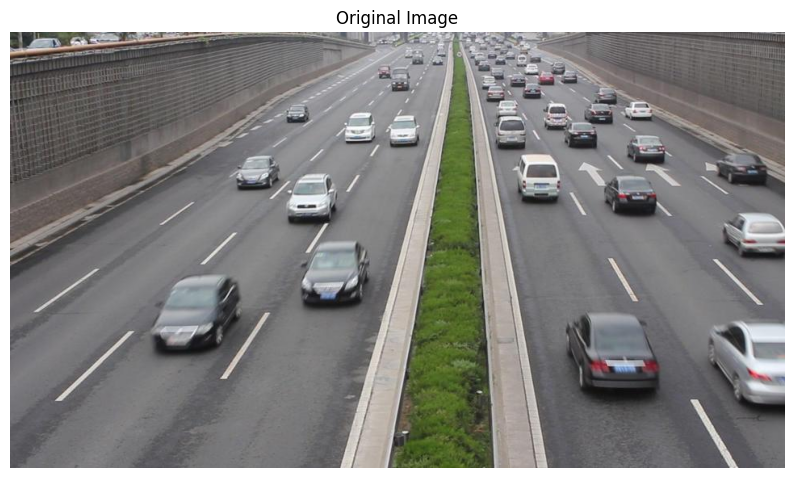

In [ ]:
image_path = 'raw.jpg'
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

h, w = img.shape[:2]
print(f"Image size: {w} x {h}")
show_bgr(img, 'Original Image')

## 3) Color masking (white + yellow lanes)
Convert to HLS and keep likely lane colors only.

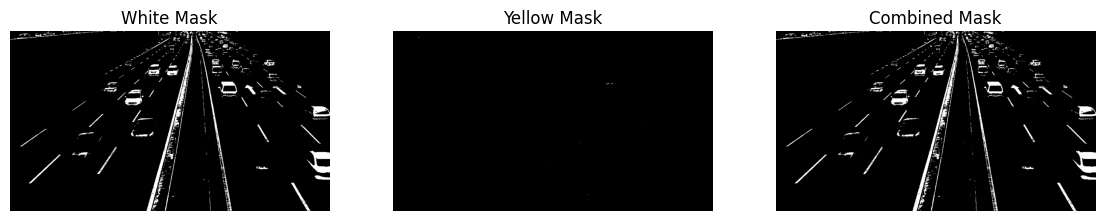

In [ ]:
hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)

white_mask = cv2.inRange(hls, np.array([0, 190, 0]), np.array([180, 255, 255]))
yellow_mask = cv2.inRange(hls, np.array([15, 40, 100]), np.array([35, 255, 255]))
mask = cv2.bitwise_or(white_mask, yellow_mask)

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.imshow(white_mask, cmap='gray')
plt.title('White Mask')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(yellow_mask, cmap='gray')
plt.title('Yellow Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask, cmap='gray')
plt.title('Combined Mask')
plt.axis('off')
plt.show()

## 4) Edge detection + road Region of Interest (ROI)
Find lane edges and keep only the road area where lanes are expected.

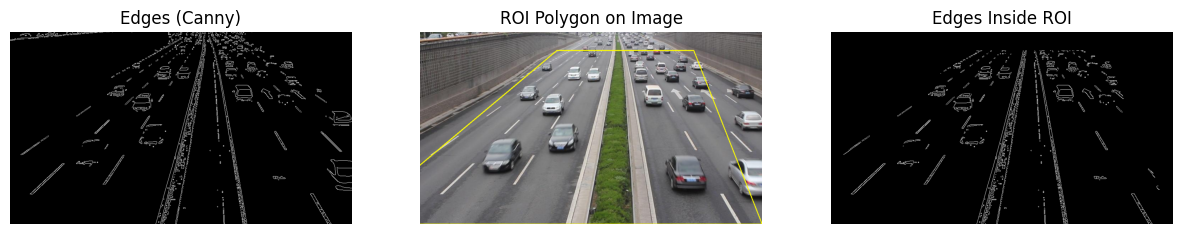

In [ ]:
edges = cv2.Canny(mask, 50, 150)

roi_poly = np.array(
    [[(0-200, h), (w+200, h), (int(w * 0.8), int(h * 0.1)), (int(w * 0.4), int(h * 0.1))]],
    np.int32,
)

roi_mask = np.zeros_like(edges)
cv2.fillPoly(roi_mask, roi_poly, 255)
masked_edges = cv2.bitwise_and(edges, roi_mask)

roi_overlay = img.copy()
cv2.polylines(roi_overlay, roi_poly, isClosed=True, color=(0, 255, 255), thickness=2)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(edges, cmap='gray')
plt.title('Edges (Canny)')
plt.axis('off')

plt.subplot(1, 3, 2)
show_roi = cv2.cvtColor(roi_overlay, cv2.COLOR_BGR2RGB)
plt.imshow(show_roi)
plt.title('ROI Polygon on Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(masked_edges, cmap='gray')
plt.title('Edges Inside ROI')
plt.axis('off')
plt.show()

## 5) Detect line segments (Hough Transform)
Find candidate line segments from ROI edges.

Hough line segments found: 92


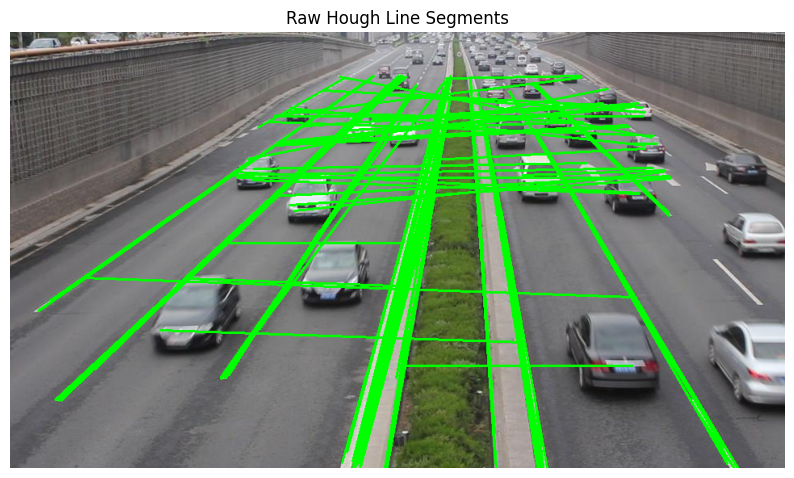

In [ ]:
lines = cv2.HoughLinesP(
    masked_edges, 1, np.pi / 180, 30, minLineLength=30, maxLineGap=200
)

line_preview = img.copy()
line_count = 0

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_preview, (x1, y1), (x2, y2), (0, 255, 0), 2)
        line_count += 1

print(f'Hough line segments found: {line_count}')
show_bgr(line_preview, 'Raw Hough Line Segments')

## 6) Filter noisy lines and cluster similar ones
We remove near-horizontal noise, then group similar lane segments using DBSCAN.

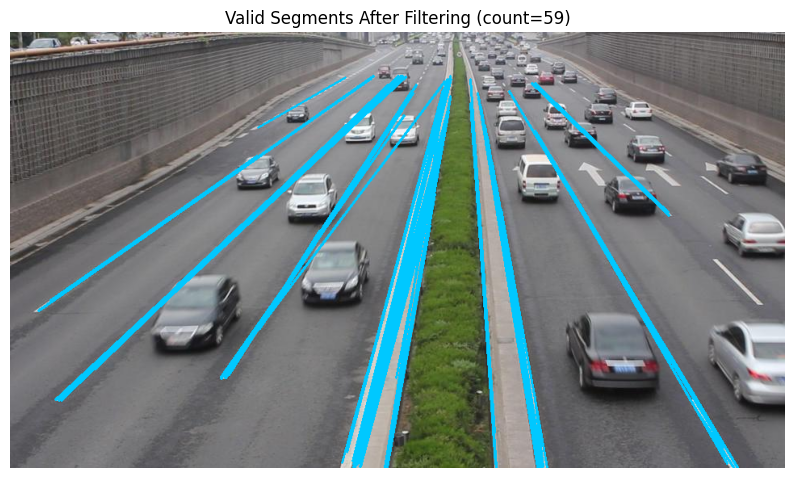

Clusters found: 10


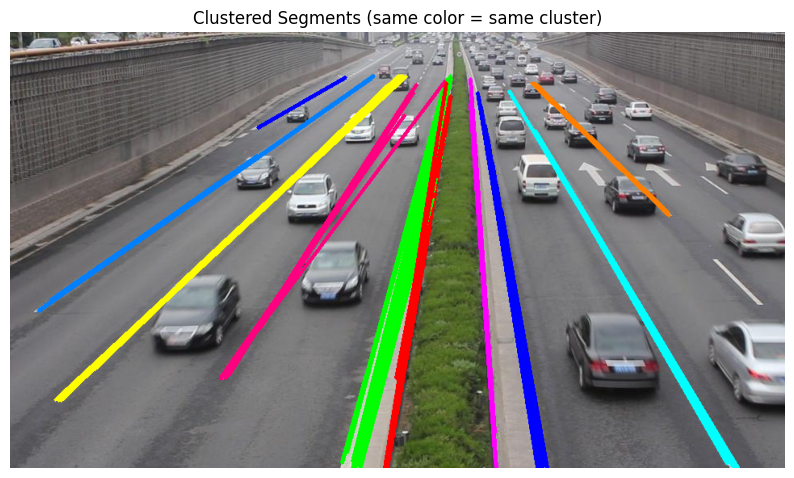

In [ ]:
features = []
points_per_cluster = {}
valid_segments_img = img.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x1 == x2:
            continue

        m = (y2 - y1) / (x2 - x1)
        if abs(m) < 0.35:
            continue

        b = y1 - m * x1
        x_bottom = (h - b) / m
        theta = np.arctan(m)

        features.append([x_bottom / w, theta])
        points_per_cluster[len(features) - 1] = [(x1, y1), (x2, y2)]

        cv2.line(valid_segments_img, (x1, y1), (x2, y2), (255, 200, 0), 2)

show_bgr(valid_segments_img, f'Valid Segments After Filtering (count={len(features)})')

if features:
    db = DBSCAN(eps=0.05, min_samples=1).fit(features)
    labels = db.labels_
else:
    labels = np.array([])

cluster_img = img.copy()
cluster_colors = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255),
    (255, 255, 0), (255, 0, 255), (0, 255, 255),
    (255, 128, 0), (128, 0, 255), (0, 128, 255)
]

for idx, label in enumerate(labels):
    color = cluster_colors[int(label) % len(cluster_colors)]
    p1, p2 = points_per_cluster[idx]
    cv2.line(cluster_img, p1, p2, color, 3)

if labels.size > 0:
    print(f'Clusters found: {len(set(labels))}')
else:
    print('No valid features to cluster.')

show_bgr(cluster_img, 'Clustered Segments (same color = same cluster)')

## 7) Fit one master lane line per cluster (final output)
Use Linear Regression on clustered points to draw smooth, consolidated lane markers.

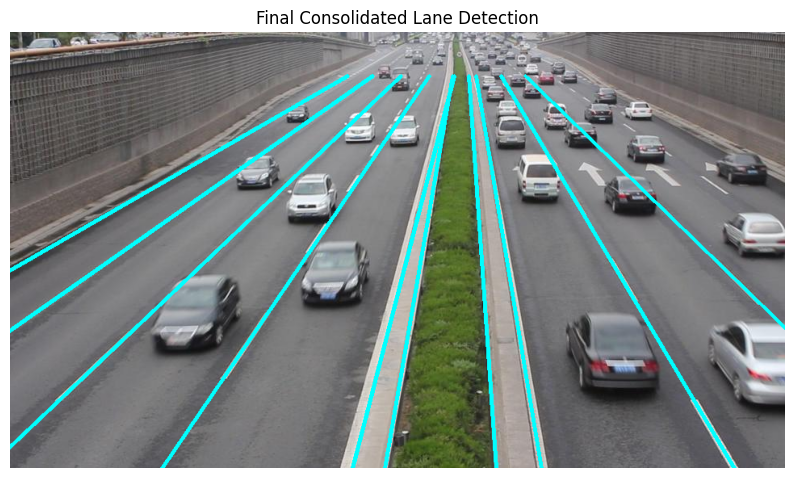

In [ ]:
from sklearn.linear_model import LinearRegression

final_result = img.copy()

if labels.size > 0:
    for cluster_id in sorted(set(labels)):
        indices = np.where(labels == cluster_id)[0]
        all_pts = []

        for idx in indices:
            all_pts.extend(points_per_cluster[idx])

        all_pts = np.array(all_pts)
        X = all_pts[:, 1].reshape(-1, 1)
        y = all_pts[:, 0]

        model = LinearRegression().fit(X, y)

        y_range = np.array([h, int(h * 0.1)], dtype=np.int32)
        x_preds = np.asarray(model.predict(y_range.reshape(-1, 1))).ravel()

        pt1 = (int(x_preds[0]), int(y_range[0]))
        pt2 = (int(x_preds[1]), int(y_range[1]))

        cv2.line(final_result, pt1, pt2, (255, 255, 0), 4)

show_bgr(final_result, 'Final Consolidated Lane Detection')

## 8) Quick recap for students
- **Masking** keeps lane colors (white/yellow).
- **Edges + ROI** focus on useful road structure.
- **Hough lines** finds many short candidate segments.
- **Filtering + clustering** groups segments belonging to same lane marker.
- **Regression** draws one clean line per lane marker.